# 2Wiki attention analysis: cache-off block attention on sentence DB vs MatKV-1024 DB

Goal:
- Inspect the first 3 `longbench-2wiki` queries.
- Compare two **cache-off** prompt constructions:
  - sentence/subchunk DB path used by `run/eval.sh`
  - `matkv_1024` DB path used by `run/eval_matkv.sh`
- Separate the prompt tail into:
  - `system_prompt`
  - `query`
- Compare two stages:
  - `prefill`
  - `decode first 4 steps average`

Interpretation:
- This does **not** prove the claim by itself.
- It provides supporting evidence for the claim that losing some cross-chunk relationships can be relatively harmless if the model relies more on `query/system-conditioned evidence chunk` links than on `chunk <-> chunk` links.

In [2]:
import gc
import json
import os
import sys
import types
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from transformers import DynamicCache, logging


def resolve_repo_root() -> Path:
    fallback_roots = [
        Path('/mnt/nvme1/dongseob/matkv'),
        Path.cwd().resolve(),
        *Path.cwd().resolve().parents,
    ]
    explicit = os.environ.get("MATKV_REPO_ROOT")
    if explicit:
        fallback_roots.insert(0, Path(explicit).resolve())
    seen = set()
    for candidate in fallback_roots:
        candidate = candidate.resolve()
        if str(candidate) in seen:
            continue
        seen.add(str(candidate))
        if (candidate / 'src').exists() and (candidate / 'test').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate repo root containing src/ and test/. '
        'Set MATKV_REPO_ROOT or edit the fallback path in the first cell.'
    )


ROOT = resolve_repo_root()
SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Notebook-only stub: avoid DeepSpeed op_builder import-time linker checks.
if 'deepspeed.ops.op_builder' not in sys.modules:
    op_builder_stub = types.ModuleType('deepspeed.ops.op_builder')

    class _DummyBuilder:
        def load(self):
            return self
        def gds_handle(self):
            return None
        def aio_handle(self):
            return None

    op_builder_stub.GDSBuilder = _DummyBuilder
    op_builder_stub.AsyncIOBuilder = _DummyBuilder
    sys.modules['deepspeed.ops.op_builder'] = op_builder_stub

from model import LLMModel
from vectordb import ChromaDB
from compressor.compressor import compress_docs, initialize_compressor

logging.set_verbosity_error()
sns.set_theme(style='whitegrid')
print('ROOT:', ROOT)

/home/dongseob/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /mnt/nvme1/dongseob/matkv


## Config

Layer meaning in all heatmaps below:
- select layers by `LAYER_MODE`
- average over the selected layers
- average over heads inside each selected layer

Default:
- `LAYER_MODE = "last8"`
- `DECODE_STEPS = 4`

In [3]:
DATASET = 'longbench-2wiki'
QUERY_INDICES = [0, 1, 2]
TOP_K = 5
LAYER_MODE = 'last8'  # options: 'all', 'last8', 'last4'
DECODE_STEPS = 4


def resolve_dataset_path(dataset_name: str) -> Path:
    explicit = os.environ.get('DATASET_PATH')
    if explicit:
        return Path(explicit)
    dataset_prefix = os.environ.get('DATASET_PREFIX')
    if dataset_prefix:
        return Path(dataset_prefix) / dataset_name
    default_path = Path('/mnt/nvme1/datasets') / dataset_name
    if default_path.exists():
        return default_path
    raise FileNotFoundError(f'Could not resolve dataset path for {dataset_name}')


def load_jsonl_rows(path: Path) -> List[dict]:
    rows = []
    with path.open(encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


DATASET_PATH = resolve_dataset_path(DATASET)
QUERY_FILE = DATASET_PATH / 'questions' / 'query.jsonl'
SENT_DB_DIR = DATASET_PATH / 'sent' / 'db'
MATKV_DB_DIR = DATASET_PATH / 'matkv_1024' / 'db'

query_rows = load_jsonl_rows(QUERY_FILE)
queries = [query_rows[idx]['query'] for idx in QUERY_INDICES]

print('dataset_path:', DATASET_PATH)
print('queries:')
for idx, q in zip(QUERY_INDICES, queries):
    print(f'  {idx}: {q}')
COMPARE_EMBED_DIR = os.environ.get('COMPARE_EMBED_DIR', str(DATASET_PATH / 'sent' / 'compare_embed'))
os.environ['COMPARE_EMBED_DIR'] = COMPARE_EMBED_DIR
os.environ.setdefault('COMPARE_EMBED_MAX_RESIDENT_SHARDS', '4')
print('COMPARE_EMBED_DIR:', COMPARE_EMBED_DIR)


dataset_path: /mnt/nvme1/datasets/longbench-2wiki
queries:
  0: Where was the wife of Francis I Rákóczi born?
  1: Who is Sobe (Sister Of Saint Anne)'s grandchild?
  2: Where does the director of film Man At Bath work at?
COMPARE_EMBED_DIR: /mnt/nvme1/datasets/longbench-2wiki/sent/compare_embed


In [4]:
model = LLMModel(model_name='meta-llama/Llama-3.1-8B-Instruct')
sent_db = ChromaDB(db_dir=str(SENT_DB_DIR))
matkv_db = ChromaDB(db_dir=str(MATKV_DB_DIR))
initialize_compressor(option='compare_all_materialized')


LOADING MODEL meta-llama/Llama-3.1-8B-Instruct ...


Loading checkpoint shards: 100%|██████████| 4/4 [00:06<00:00,  1.55s/it]


9.724458009004593
MODEL LOADED
Comparison summarization enabled. Initializing local embedding model...


In [5]:
def _sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def select_layer_indices(num_layers: int, mode: str) -> List[int]:
    if mode == 'all':
        return list(range(num_layers))
    if mode == 'last8':
        return list(range(max(0, num_layers - 8), num_layers))
    if mode == 'last4':
        return list(range(max(0, num_layers - 4), num_layers))
    raise ValueError(mode)


def _manual_layerwise_forward(
    model: LLMModel,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    position_ids: torch.Tensor,
    initial_cache: DynamicCache | None,
):
    base_model = model.model.model
    inputs_embeds = base_model.embed_tokens(input_ids)
    cache = initial_cache if initial_cache is not None else DynamicCache()
    cache_position = position_ids[0]
    causal_mask = base_model._update_causal_mask(
        attention_mask=attention_mask,
        input_tensor=inputs_embeds,
        cache_position=cache_position,
        past_key_values=cache,
        output_attentions=True,
    )
    position_embeddings = base_model.rotary_emb(inputs_embeds, position_ids)

    hidden_states = inputs_embeds
    attentions = []
    for layer in base_model.layers:
        layer_outputs = layer(
            hidden_states,
            attention_mask=causal_mask,
            position_ids=position_ids,
            past_key_value=cache,
            output_attentions=True,
            use_cache=True,
            cache_position=cache_position,
            position_embeddings=position_embeddings,
        )
        hidden_states = layer_outputs[0]
        attentions.append(layer_outputs[1][0].detach().cpu().to(torch.float32))
    hidden_states = base_model.norm(hidden_states)
    return hidden_states, tuple(attentions), cache


def block_mass_matrix(attentions, blocks: List[dict], layer_mode: str = 'last8') -> pd.DataFrame:
    layer_indices = select_layer_indices(len(attentions), layer_mode)
    per_layer = []
    for layer_idx in layer_indices:
        per_layer.append(attentions[layer_idx].mean(dim=0))
    stacked = torch.stack(per_layer, dim=0)

    mat = torch.zeros((len(blocks), len(blocks)), dtype=torch.float32)
    for i, src in enumerate(blocks):
        src_slice = slice(src['start'], src['end'])
        for j, tgt in enumerate(blocks):
            tgt_slice = slice(tgt['start'], tgt['end'])
            tgt_mass = stacked[:, src_slice, tgt_slice].sum(dim=-1)
            mat[i, j] = tgt_mass.mean()
    labels = [block['name'] for block in blocks]
    return pd.DataFrame(mat.numpy(), index=labels, columns=labels)


def decode_rows_to_block_df(decode_rows: torch.Tensor, blocks: List[dict]) -> pd.DataFrame:
    data = []
    for src_idx in range(decode_rows.shape[0]):
        row = []
        for block in blocks:
            row.append(float(decode_rows[src_idx, block['start']:block['end']].sum().item()))
        data.append(row)
    return pd.DataFrame(data, index=[f'decode_{i+1}' for i in range(decode_rows.shape[0])], columns=[b['name'] for b in blocks])


def build_doc_level_prompt_parts(model: LLMModel, docs: List, query: str):
    parts = []
    for doc_idx, doc in enumerate(docs):
        if doc.text and doc.text.strip():
            parts.append((f'chunk_{doc_idx}', model.format_passage_chunk(doc.text)))
    parts.append(('system_prompt', f"{model.SYSTEM_PROMPT}"))
    parts.append(('query', f"Question: {query.strip()}\nAnswer:"))
    return parts


def build_materialized_doc_grouped_prompt_parts(model: LLMModel, docs: List, query: str):
    parts = []
    for doc_idx, doc in enumerate(docs):
        selected_chunk_texts = []
        for chunk_text in doc.metadata.get('chunk_texts', []):
            if chunk_text and chunk_text.strip():
                selected_chunk_texts.append(model.format_passage_chunk(chunk_text))
        if selected_chunk_texts:
            parts.append((f'chunk_{doc_idx}', ''.join(selected_chunk_texts)))
    parts.append(('system_prompt', f"{model.SYSTEM_PROMPT}"))
    parts.append(('query', f"Question: {query.strip()}\nAnswer:"))
    return parts


def build_materialized_subchunk_prompt_parts(model: LLMModel, docs: List, query: str):
    parts = []
    chunk_idx = 0
    for doc in docs:
        for chunk_text in doc.metadata.get('chunk_texts', []):
            if chunk_text and chunk_text.strip():
                parts.append((f'chunk_{chunk_idx}', model.format_passage_chunk(chunk_text)))
                chunk_idx += 1
    parts.append(('system_prompt', f"{model.SYSTEM_PROMPT}\n\n"))
    parts.append(('query', f"Question: {query.strip()}\nAnswer:"))
    return parts


def build_prompt_and_blocks_from_parts(model: LLMModel, parts: List[Tuple[str, str]]):
    empty_prefix_len = len(model.tokenizer('', add_special_tokens=True, truncation=False)['input_ids'])
    blocks = []
    prefix = ''
    prev_len = empty_prefix_len
    for name, part in parts:
        prefix += part
        curr_len = len(model.tokenizer(prefix, add_special_tokens=True, truncation=False)['input_ids'])
        blocks.append({'name': name, 'start': prev_len, 'end': curr_len})
        prev_len = curr_len
    return prefix, blocks


def collect_decode_rows(model: LLMModel, prefill_hidden: torch.Tensor, prefill_cache: DynamicCache, attention_mask: torch.Tensor, base_seq_len: int, decode_steps: int, layer_mode: str):
    layer_indices = None
    next_token_logits = model.model.lm_head(prefill_hidden[:, -1, :])
    next_token_id = next_token_logits.argmax(dim=-1, keepdim=True)
    current_cache = prefill_cache
    current_attention_mask = attention_mask
    current_pos = base_seq_len
    rows = []
    for _ in range(decode_steps):
        current_attention_mask = torch.cat([current_attention_mask, torch.ones((1, 1), dtype=current_attention_mask.dtype, device=current_attention_mask.device)], dim=1)
        position_ids = torch.tensor([[current_pos]], device=next_token_id.device, dtype=torch.long)
        _sync()
        with torch.no_grad():
            hidden_states, attentions, current_cache = _manual_layerwise_forward(model, next_token_id, current_attention_mask, position_ids, current_cache)
        _sync()
        if layer_indices is None:
            layer_indices = select_layer_indices(len(attentions), layer_mode)
        row = torch.stack([attentions[layer_idx].mean(dim=0)[0] for layer_idx in layer_indices], dim=0).mean(dim=0)
        rows.append(row[:base_seq_len].contiguous())
        next_token_logits = model.model.lm_head(hidden_states[:, -1, :])
        next_token_id = next_token_logits.argmax(dim=-1, keepdim=True)
        current_pos += 1
        del hidden_states, attentions, position_ids
        gc.collect()
        torch.cuda.empty_cache()
    return torch.stack(rows, dim=0)


def probe_cacheoff_parts(model: LLMModel, parts: List[Tuple[str, str]], layer_mode: str = 'last8', decode_steps: int = 4):
    prompt, blocks = build_prompt_and_blocks_from_parts(model, parts)
    tokenized = model.tokenizer([prompt], return_tensors='pt', padding=False, truncation=False).to('cuda')
    input_ids = tokenized['input_ids']
    attention_mask = tokenized['attention_mask']
    position_ids = torch.arange(input_ids.shape[1], device=input_ids.device, dtype=torch.long).unsqueeze(0)
    _sync()
    with torch.no_grad():
        hidden_states, attentions, prefill_cache = _manual_layerwise_forward(model, input_ids, attention_mask, position_ids, None)
    _sync()
    prefill_df = block_mass_matrix(attentions, blocks, layer_mode=layer_mode)
    decode_rows = collect_decode_rows(model, hidden_states, prefill_cache, attention_mask, input_ids.shape[1], decode_steps, layer_mode)
    decode_df = decode_rows_to_block_df(decode_rows, blocks)
    decode_avg = decode_df.mean(axis=0)
    chunk_names = [b['name'] for b in blocks if b['name'].startswith('chunk_')]
    query_name = 'query'
    sys_name = 'system_prompt'
    prefill_query_to_chunk_pair = float(np.mean([prefill_df.loc[query_name, c] for c in chunk_names])) if chunk_names else 0.0
    prefill_system_to_chunk_pair = float(np.mean([prefill_df.loc[sys_name, c] for c in chunk_names])) if chunk_names else 0.0
    prefill_cross_chunk_pair = float(np.mean([prefill_df.loc[src, tgt] for src in chunk_names for tgt in chunk_names if src != tgt])) if len(chunk_names) >= 2 else 0.0
    decode_to_all_chunks = float(sum(decode_avg[c] for c in chunk_names))
    del tokenized, input_ids, attention_mask, position_ids, hidden_states, attentions, prefill_cache, decode_rows
    gc.collect()
    torch.cuda.empty_cache()
    return {
        'prompt': prompt,
        'blocks': blocks,
        'prefill_df': prefill_df,
        'decode_df': decode_df,
        'decode_avg': decode_avg,
        'summary': {
            'prefill_query_to_chunk_pair_mean': prefill_query_to_chunk_pair,
            'prefill_system_to_chunk_pair_mean': prefill_system_to_chunk_pair,
            'prefill_cross_chunk_pair_mean': prefill_cross_chunk_pair,
            'prefill_query_over_cross_chunk': prefill_query_to_chunk_pair / max(prefill_cross_chunk_pair, 1e-12),
            'prefill_system_over_cross_chunk': prefill_system_to_chunk_pair / max(prefill_cross_chunk_pair, 1e-12),
            'decode_first4_to_all_chunks_mass': decode_to_all_chunks,
        },
    }


## Retrieve the first 3 samples from both cache-off DBs

In [6]:
sent_docs_per_query = sent_db.find_top_k_docs(top_k=TOP_K, queries=queries)
matkv_docs_per_query = matkv_db.find_top_k_docs(top_k=TOP_K, queries=queries)

for local_idx, query_idx in enumerate(QUERY_INDICES):
    print(f'query {query_idx}')
    print('  sent docs :', len(sent_docs_per_query[local_idx]))
    print('  matkv docs:', len(matkv_docs_per_query[local_idx]))

query 0
  sent docs : 5
  matkv docs: 5
query 1
  sent docs : 5
  matkv docs: 5
query 2
  sent docs : 5
  matkv docs: 5


## Sentence/subchunk DB: prefill and decode-first4 block attention

In [7]:
sent_results = {}
for local_idx, query_idx in enumerate(QUERY_INDICES):
    parts = build_doc_level_prompt_parts(model, sent_docs_per_query[local_idx], queries[local_idx])
    sent_results[query_idx] = probe_cacheoff_parts(model=model, parts=parts, layer_mode=LAYER_MODE, decode_steps=DECODE_STEPS)


In [8]:
def summarize_result_dict(results: Dict[int, dict]) -> pd.DataFrame:
    rows = []
    for query_idx in QUERY_INDICES:
        summary = results[query_idx]['summary']
        rows.append({'query_idx': query_idx, **summary})
    return pd.DataFrame(rows)

sent_summary_df = summarize_result_dict(sent_results)
sent_summary_df

,query_idx,prefill_query_to_chunk_pair_mean,prefill_system_to_chunk_pair_mean,prefill_cross_chunk_pair_mean,prefill_query_over_cross_chunk,prefill_system_over_cross_chunk,decode_first4_to_all_chunks_mass
0,0,0.038047,0.013996,0.012297,3.093857,1.138103,0.152181
1,1,0.038279,0.013509,0.008062,4.747884,1.675526,0.151013
2,2,0.042952,0.016832,0.009691,4.432158,1.736834,0.147907


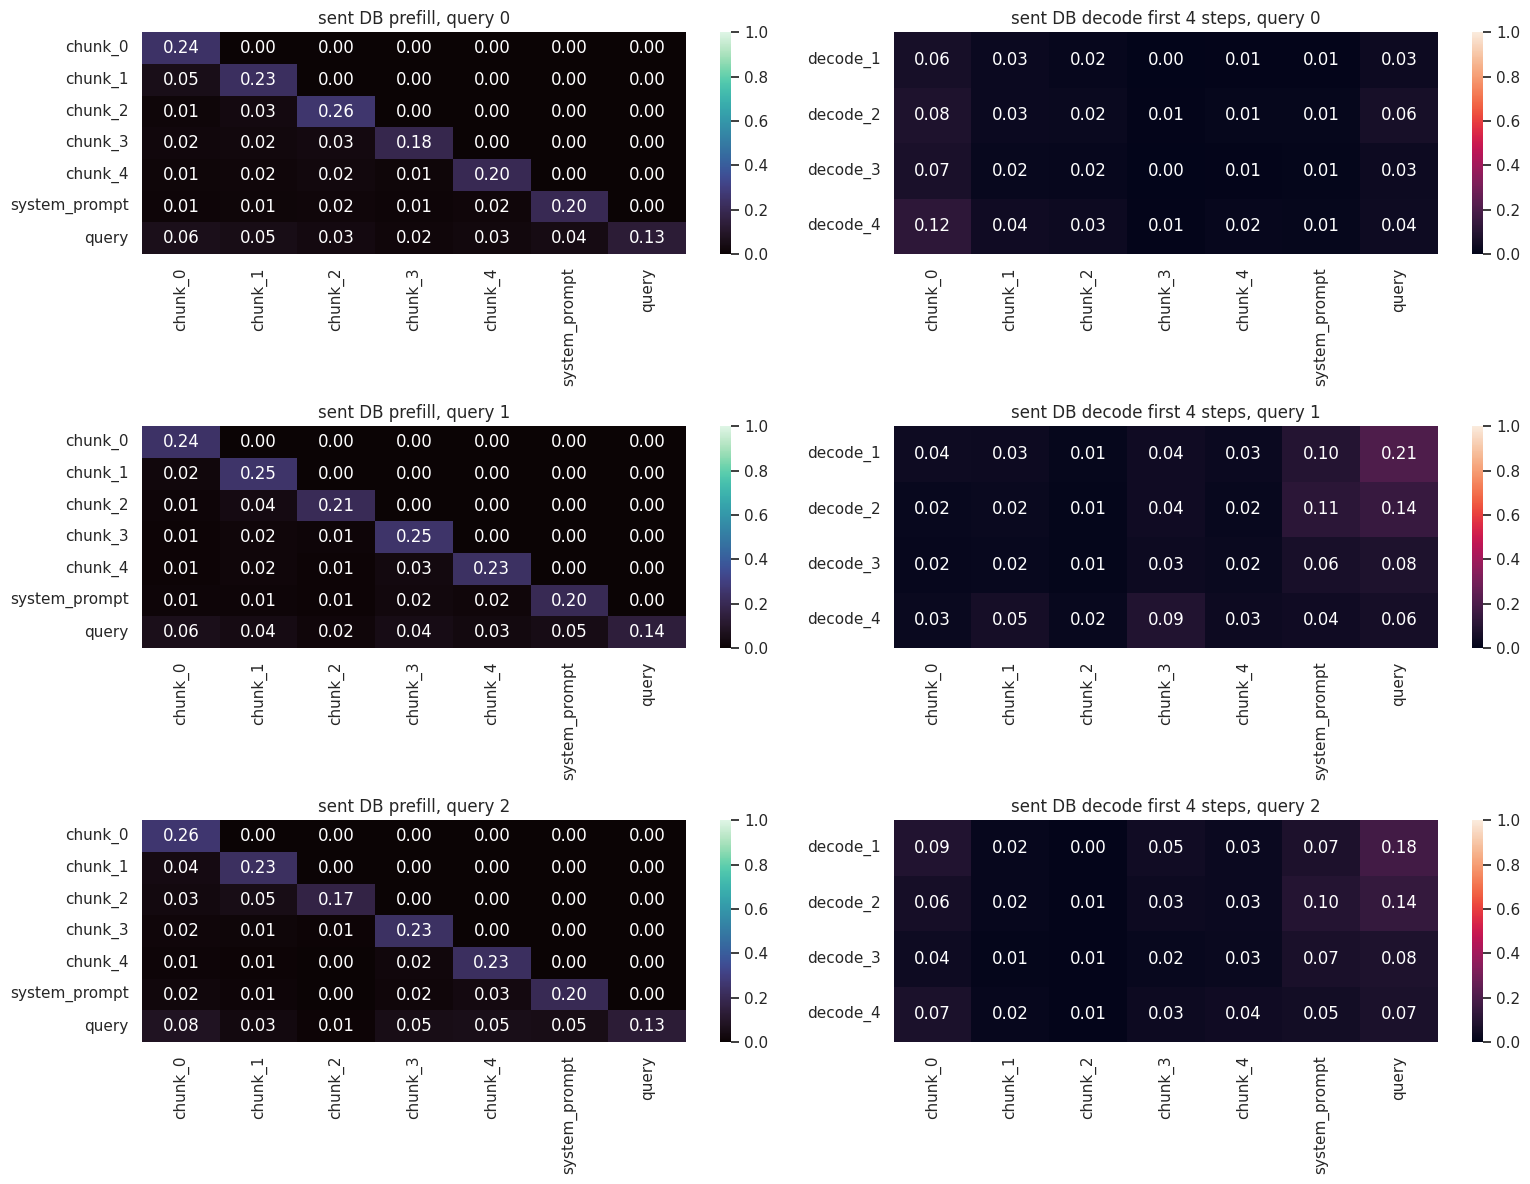

In [9]:
fig, axes = plt.subplots(len(QUERY_INDICES), 2, figsize=(16, 4 * len(QUERY_INDICES)))
if len(QUERY_INDICES) == 1:
    axes = np.array([axes])
for row_idx, query_idx in enumerate(QUERY_INDICES):
    sns.heatmap(sent_results[query_idx]['prefill_df'], annot=True, fmt='.2f', cmap='mako', ax=axes[row_idx, 0], vmin=0.0, vmax=1.0)
    axes[row_idx, 0].set_title(f'sent DB prefill, query {query_idx}')
    sns.heatmap(sent_results[query_idx]['decode_df'], annot=True, fmt='.2f', cmap='rocket', ax=axes[row_idx, 1], vmin=0.0, vmax=1.0)
    axes[row_idx, 1].set_title(f'sent DB decode first {DECODE_STEPS} steps, query {query_idx}')
plt.tight_layout()
plt.show()

## MatKV-1024 DB: prefill and decode-first4 block attention (cache-off)

In [10]:
matkv_results = {}
for local_idx, query_idx in enumerate(QUERY_INDICES):
    parts = build_doc_level_prompt_parts(model, matkv_docs_per_query[local_idx], queries[local_idx])
    matkv_results[query_idx] = probe_cacheoff_parts(model=model, parts=parts, layer_mode=LAYER_MODE, decode_steps=DECODE_STEPS)


In [11]:
matkv_summary_df = summarize_result_dict(matkv_results)
matkv_summary_df

,query_idx,prefill_query_to_chunk_pair_mean,prefill_system_to_chunk_pair_mean,prefill_cross_chunk_pair_mean,prefill_query_over_cross_chunk,prefill_system_over_cross_chunk,decode_first4_to_all_chunks_mass
0,0,0.038446,0.013556,0.014351,2.678934,0.944589,0.138173
1,1,0.036585,0.012925,0.008975,4.076538,1.440211,0.136948
2,2,0.040693,0.016008,0.018974,2.144645,0.843685,0.133630


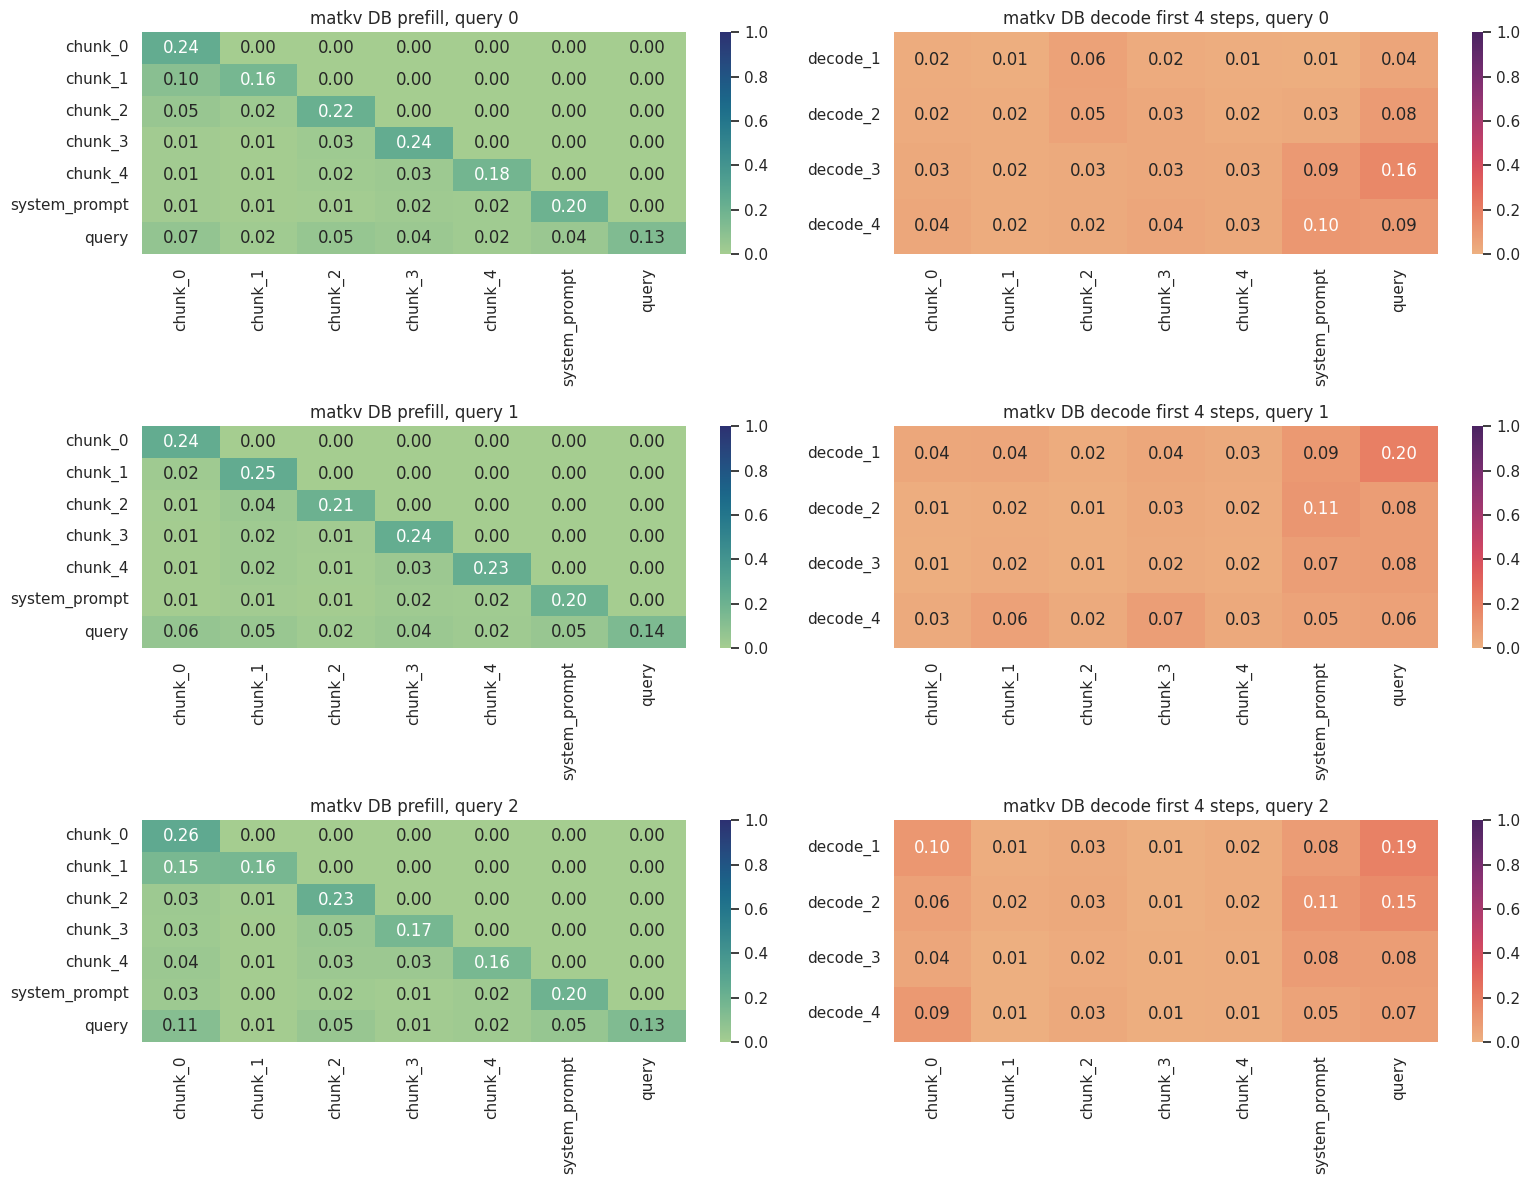

In [12]:
fig, axes = plt.subplots(len(QUERY_INDICES), 2, figsize=(16, 4 * len(QUERY_INDICES)))
if len(QUERY_INDICES) == 1:
    axes = np.array([axes])
for row_idx, query_idx in enumerate(QUERY_INDICES):
    sns.heatmap(matkv_results[query_idx]['prefill_df'], annot=True, fmt='.2f', cmap='crest', ax=axes[row_idx, 0], vmin=0.0, vmax=1.0)
    axes[row_idx, 0].set_title(f'matkv DB prefill, query {query_idx}')
    sns.heatmap(matkv_results[query_idx]['decode_df'], annot=True, fmt='.2f', cmap='flare', ax=axes[row_idx, 1], vmin=0.0, vmax=1.0)
    axes[row_idx, 1].set_title(f'matkv DB decode first {DECODE_STEPS} steps, query {query_idx}')
plt.tight_layout()
plt.show()

## Side-by-side summary

In [13]:
comparison_rows = []
for query_idx in QUERY_INDICES:
    s = sent_results[query_idx]['summary']
    m = matkv_results[query_idx]['summary']
    comparison_rows.append({
        'query_idx': query_idx,
        'sent_prefill_query_to_chunk_pair': s['prefill_query_to_chunk_pair_mean'],
        'sent_prefill_system_to_chunk_pair': s['prefill_system_to_chunk_pair_mean'],
        'sent_prefill_cross_chunk_pair': s['prefill_cross_chunk_pair_mean'],
        'sent_prefill_query_over_cross': s['prefill_query_over_cross_chunk'],
        'sent_decode_first4_to_all_chunks': s['decode_first4_to_all_chunks_mass'],
        'matkv_prefill_query_to_chunk_pair': m['prefill_query_to_chunk_pair_mean'],
        'matkv_prefill_system_to_chunk_pair': m['prefill_system_to_chunk_pair_mean'],
        'matkv_prefill_cross_chunk_pair': m['prefill_cross_chunk_pair_mean'],
        'matkv_prefill_query_over_cross': m['prefill_query_over_cross_chunk'],
        'matkv_decode_first4_to_all_chunks': m['decode_first4_to_all_chunks_mass'],
    })
comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,query_idx,sent_prefill_query_to_chunk_pair,sent_prefill_system_to_chunk_pair,sent_prefill_cross_chunk_pair,sent_prefill_query_over_cross,sent_decode_first4_to_all_chunks,matkv_prefill_query_to_chunk_pair,matkv_prefill_system_to_chunk_pair,matkv_prefill_cross_chunk_pair,matkv_prefill_query_over_cross,matkv_decode_first4_to_all_chunks
0,0,0.038047,0.013996,0.012297,3.093857,0.152181,0.038446,0.013556,0.014351,2.678934,0.138173
1,1,0.038279,0.013509,0.008062,4.747884,0.151013,0.036585,0.012925,0.008975,4.076538,0.136948
2,2,0.042952,0.016832,0.009691,4.432158,0.147907,0.040693,0.016008,0.018974,2.144645,0.133630


In [14]:
agg = pd.DataFrame({
    'sent_mean': sent_summary_df.drop(columns=['query_idx']).mean(),
    'matkv_mean': matkv_summary_df.drop(columns=['query_idx']).mean(),
})
agg

,sent_mean,matkv_mean
prefill_query_to_chunk_pair_mean,0.039759,0.038575
prefill_system_to_chunk_pair_mean,0.014779,0.014163
prefill_cross_chunk_pair_mean,0.010017,0.014100
prefill_query_over_cross_chunk,4.091300,2.966706
prefill_system_over_cross_chunk,1.516821,1.076162
decode_first4_to_all_chunks_mass,0.150367,0.136250


## Reading guide

Key prefill quantities:
- `prefill_query_to_chunk_pair_mean`
  - average block attention from the `query` block to a chunk block
- `prefill_system_to_chunk_pair_mean`
  - average block attention from the `system_prompt` block to a chunk block
- `prefill_cross_chunk_pair_mean`
  - average block attention from one chunk block to a different chunk block
- `prefill_query_over_cross_chunk`
  - if larger than `1`, then `query -> chunk` is stronger than `chunk -> chunk`

Key decode quantity:
- `decode_first4_to_all_chunks_mass`
  - average total chunk attention mass across the first 4 decode steps

What would support the claim:
- `prefill_query_over_cross_chunk > 1` often enough, especially in the `matkv_1024` cache-off path
- nontrivial `decode_first4_to_all_chunks_mass`, showing that early answer formation still concentrates on chunk evidence

## Sentence DB with `compare_all_materialized` + cache-off

This section now matches the intended `eval.sh` family more closely:
- retrieve from `sent/db`
- run `compare_all_materialized`
- then build a full `cache-off` prompt from the selected `chunk_texts`
- measure `prefill` and `decode first 4 steps`

In [9]:
materialized_docs_per_query = compress_docs(
    batch_queries=queries,
    batch_top_k_docs=sent_docs_per_query,
    option='compare_all_materialized',
)

for local_idx, query_idx in enumerate(QUERY_INDICES):
    docs = materialized_docs_per_query[local_idx]
    chunk_counts = [len(doc.metadata.get('chunk_texts', [])) for doc in docs]
    print(f'query {query_idx}: docs={len(docs)}, chunk_text counts={chunk_counts}')

query 0: docs=5, chunk_text counts=[10, 19, 4, 2, 1]
query 1: docs=5, chunk_text counts=[5, 17, 1, 8, 5]
query 2: docs=5, chunk_text counts=[4, 6, 3, 9, 14]


In [10]:
materialized_results = {}
for local_idx, query_idx in enumerate(QUERY_INDICES):
    parts = build_materialized_doc_grouped_prompt_parts(model, materialized_docs_per_query[local_idx], queries[local_idx])
    materialized_results[query_idx] = probe_cacheoff_parts(
        model=model,
        parts=parts,
        layer_mode=LAYER_MODE,
        decode_steps=DECODE_STEPS,
    )


In [11]:
materialized_summary_df = summarize_result_dict(materialized_results)
materialized_summary_df

,query_idx,prefill_query_to_chunk_pair_mean,prefill_system_to_chunk_pair_mean,prefill_cross_chunk_pair_mean,prefill_query_over_cross_chunk,prefill_system_over_cross_chunk,decode_first4_to_all_chunks_mass
0,0,0.033546,0.012704,0.013751,2.439592,0.923864,0.119113
1,1,0.033855,0.013543,0.009101,3.719824,1.488032,0.129417
2,2,0.038682,0.015932,0.008687,4.452973,1.834128,0.104770


In [12]:
comparison_debug_rows = []
for local_idx, query_idx in enumerate(QUERY_INDICES):
    raw_parts = build_doc_level_prompt_parts(model, sent_docs_per_query[local_idx], queries[local_idx])
    mat_parts = build_materialized_doc_grouped_prompt_parts(model, materialized_docs_per_query[local_idx], queries[local_idx])
    raw_prompt, _ = build_prompt_and_blocks_from_parts(model, raw_parts)
    mat_prompt, _ = build_prompt_and_blocks_from_parts(model, mat_parts)
    raw_chunk_total = len(sent_docs_per_query[local_idx])
    mat_chunk_total = sum(1 for doc in materialized_docs_per_query[local_idx] if len(doc.metadata.get('chunk_texts', [])) > 0)
    raw_tok_len = len(model.tokenizer(raw_prompt, add_special_tokens=True, truncation=False)['input_ids'])
    mat_tok_len = len(model.tokenizer(mat_prompt, add_special_tokens=True, truncation=False)['input_ids'])
    comparison_debug_rows.append({
        'query_idx': query_idx,
        'raw_doc_count': raw_chunk_total,
        'materialized_doc_count': mat_chunk_total,
        'raw_prompt_token_len': raw_tok_len,
        'materialized_prompt_token_len': mat_tok_len,
        'prompt_equal': raw_prompt == mat_prompt,
    })
comparison_debug_df = pd.DataFrame(comparison_debug_rows)
comparison_debug_df


,query_idx,raw_doc_count,materialized_doc_count,raw_prompt_token_len,materialized_prompt_token_len,prompt_equal
0,0,5,5,3804,1712,False
1,1,5,5,4281,1807,False
2,2,5,5,3415,1415,False


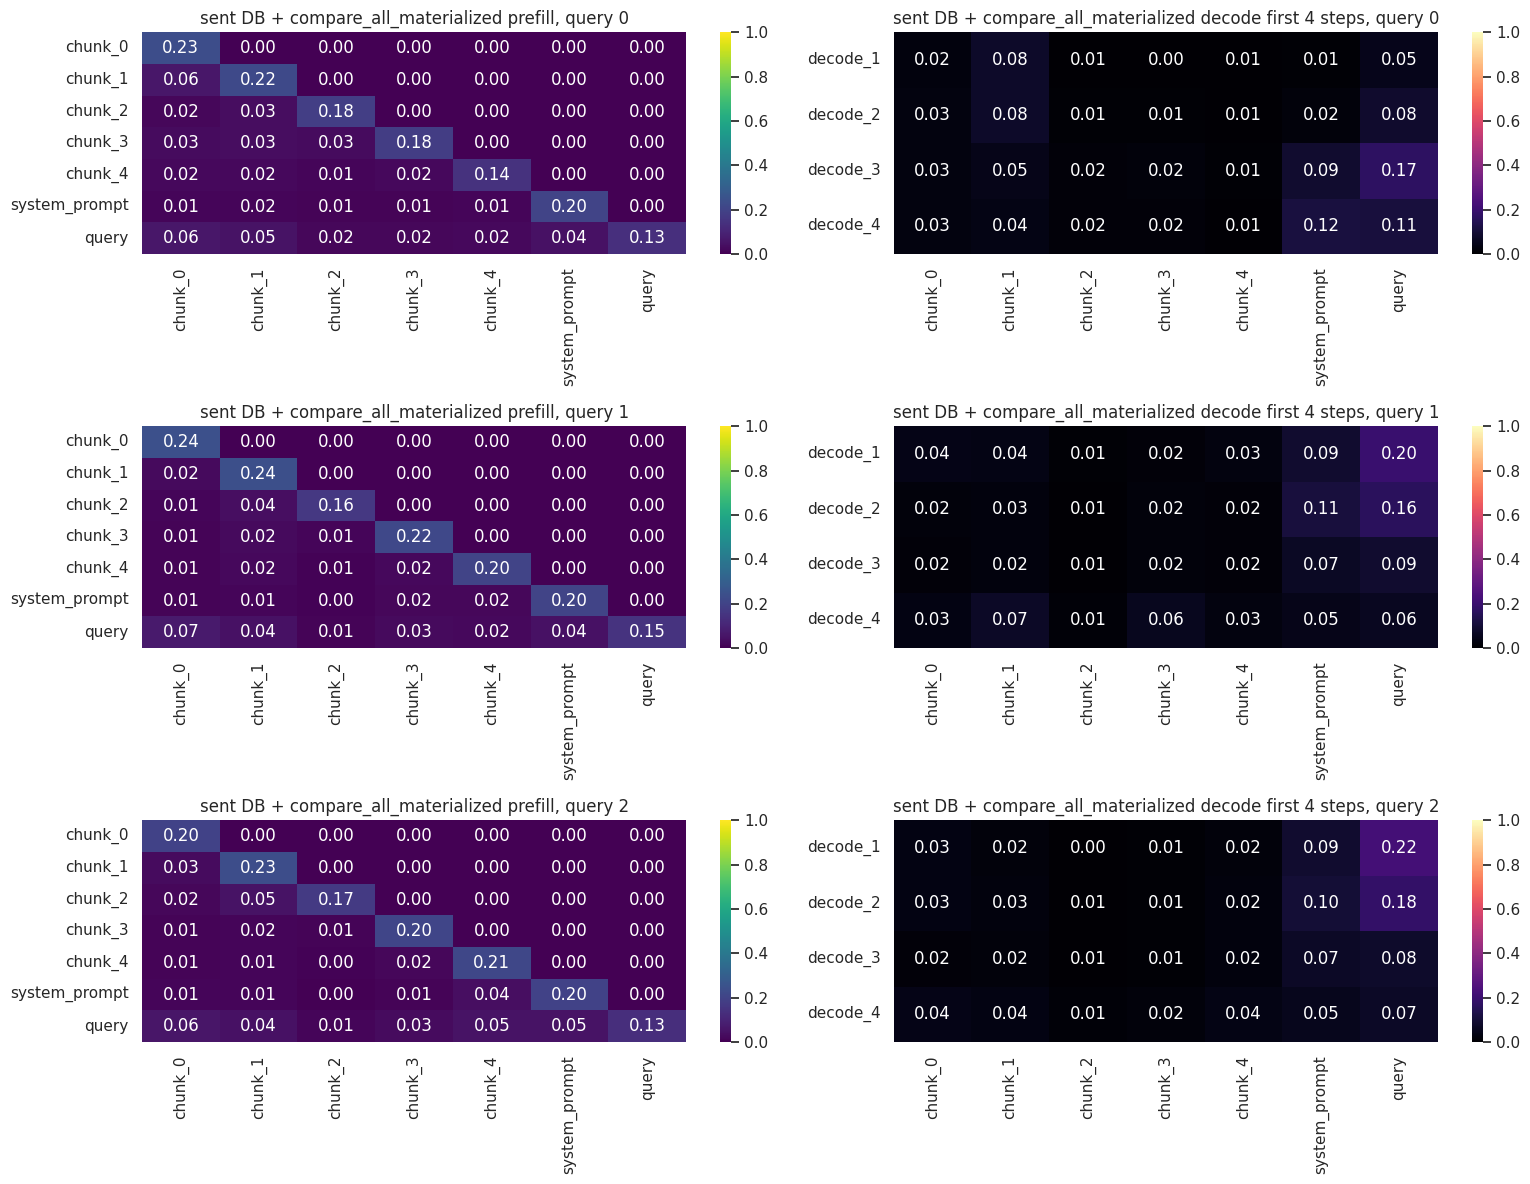

In [13]:
fig, axes = plt.subplots(len(QUERY_INDICES), 2, figsize=(16, 4 * len(QUERY_INDICES)))
if len(QUERY_INDICES) == 1:
    axes = np.array([axes])
for row_idx, query_idx in enumerate(QUERY_INDICES):
    sns.heatmap(materialized_results[query_idx]['prefill_df'], annot=True, fmt='.2f', cmap='viridis', ax=axes[row_idx, 0], vmin=0.0, vmax=1.0)
    axes[row_idx, 0].set_title(f'sent DB + compare_all_materialized prefill, query {query_idx}')
    sns.heatmap(materialized_results[query_idx]['decode_df'], annot=True, fmt='.2f', cmap='magma', ax=axes[row_idx, 1], vmin=0.0, vmax=1.0)
    axes[row_idx, 1].set_title(f'sent DB + compare_all_materialized decode first {DECODE_STEPS} steps, query {query_idx}')
plt.tight_layout()
plt.show()

## Materialized sentence-level (subchunk-level) attention map

The previous materialized section regrouped selected subchunks back into their original retrieved document block.
The cells below keep each selected subchunk as its own block, so you can directly inspect cross-subchunk attention inside the `compare_all_materialized + cache-off` case.


In [14]:
materialized_subchunk_results = {}
for local_idx, query_idx in enumerate(QUERY_INDICES):
    parts = build_materialized_subchunk_prompt_parts(model, materialized_docs_per_query[local_idx], queries[local_idx])
    materialized_subchunk_results[query_idx] = probe_cacheoff_parts(
        model=model,
        parts=parts,
        layer_mode=LAYER_MODE,
        decode_steps=DECODE_STEPS,
    )


In [15]:
materialized_subchunk_summary_df = summarize_result_dict(materialized_subchunk_results)
materialized_subchunk_summary_df


,query_idx,prefill_query_to_chunk_pair_mean,prefill_system_to_chunk_pair_mean,prefill_cross_chunk_pair_mean,prefill_query_over_cross_chunk,prefill_system_over_cross_chunk,decode_first4_to_all_chunks_mass
0,0,0.004532,0.001874,0.003761,1.204862,0.498116,0.125313
1,1,0.004390,0.001969,0.003489,1.258198,0.564426,0.129903
2,2,0.005216,0.002312,0.003261,1.599219,0.709052,0.109573


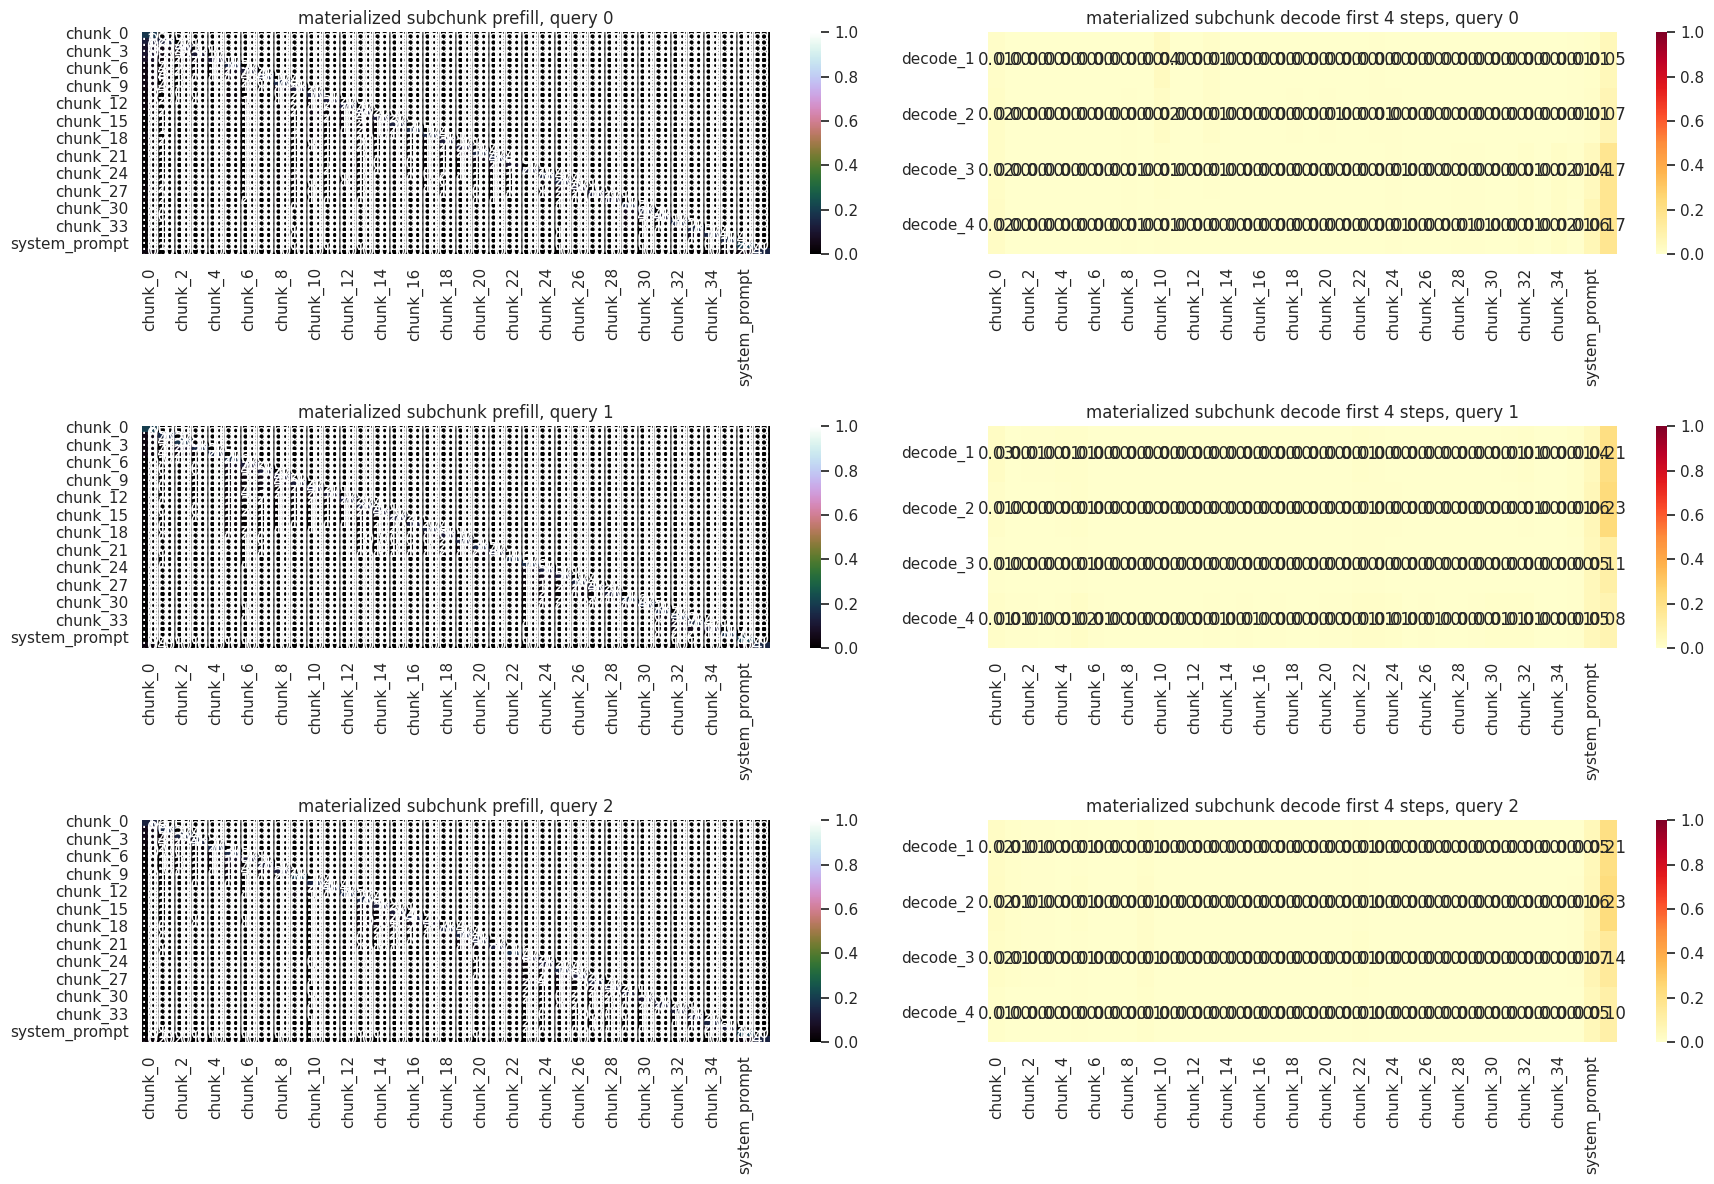

In [16]:
fig, axes = plt.subplots(len(QUERY_INDICES), 2, figsize=(18, 4 * len(QUERY_INDICES)))
if len(QUERY_INDICES) == 1:
    axes = np.array([axes])
for row_idx, query_idx in enumerate(QUERY_INDICES):
    sns.heatmap(materialized_subchunk_results[query_idx]['prefill_df'], annot=True, fmt='.2f', cmap='cubehelix', ax=axes[row_idx, 0], vmin=0.0, vmax=1.0)
    axes[row_idx, 0].set_title(f'materialized subchunk prefill, query {query_idx}')
    sns.heatmap(materialized_subchunk_results[query_idx]['decode_df'], annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[row_idx, 1], vmin=0.0, vmax=1.0)
    axes[row_idx, 1].set_title(f'materialized subchunk decode first {DECODE_STEPS} steps, query {query_idx}')
plt.tight_layout()
plt.show()


In [18]:
compare_materialized_rows = []
for query_idx in QUERY_INDICES:
    m = materialized_results[query_idx]['summary']
    base = sent_results[query_idx]['summary']
    matkv = matkv_results[query_idx]['summary']
    compare_materialized_rows.append({
        'query_idx': query_idx,
        'sent_raw_prefill_query_over_cross': base['prefill_query_over_cross_chunk'],
        'sent_materialized_prefill_query_over_cross': m['prefill_query_over_cross_chunk'],
        'sent_materialized_prefill_system_over_cross': m['prefill_system_over_cross_chunk'],
        'sent_materialized_decode_first4_to_all_chunks': m['decode_first4_to_all_chunks_mass'],
        'matkv_prefill_query_over_cross': matkv['prefill_query_over_cross_chunk'],
        'matkv_decode_first4_to_all_chunks': matkv['decode_first4_to_all_chunks_mass'],
    })
compare_materialized_df = pd.DataFrame(compare_materialized_rows)
compare_materialized_df

NameError: name 'matkv_results' is not defined

### How to interpret this section

This is the most relevant sentence/subchunk comparison in the notebook because it uses the actual
`compare_all_materialized` selector before building the `cache-off` prompt.

The most useful comparisons are:
- `sent_materialized_prefill_query_over_cross`
- `matkv_prefill_query_over_cross`
- `sent_materialized_decode_first4_to_all_chunks`
- `matkv_decode_first4_to_all_chunks`